
IMAGE PROCESSING DEMONSTRATION
Topics: Types of Images, Representation, Sampling, Quantization, Formation

✅ All operations use mathematical formulas from scratch
✅ Supports any image format (JPG, PNG, BMP, TIFF, GIF, WEBP, PGM)
✅ Auto-resizes to 720p max


📤 Please upload an image:
Click 'Choose File' button below and select your image
Or press 'Cancel' to use test image
--------------------------------------------------


Saving 6.jpg to 6.jpg

✓ Loaded: 6.jpg (408x612)

1. TYPES OF IMAGES

1. TYPES OF IMAGES

[1] Binary Image (Black & White)
    ✓ Binary image created (2 intensity levels)

[2] Grayscale Image (256 levels)
    ✓ Grayscale image (8-bit, 256 levels)

[3] Color Image (RGB)
    ✓ Color image (3 channels: R, G, B)

[4] Indexed Image
    ✓ Indexed image (4 colors mapped)

[5] Multispectral Image
    ✓ Multispectral image (4 bands: R, G, B, NIR)


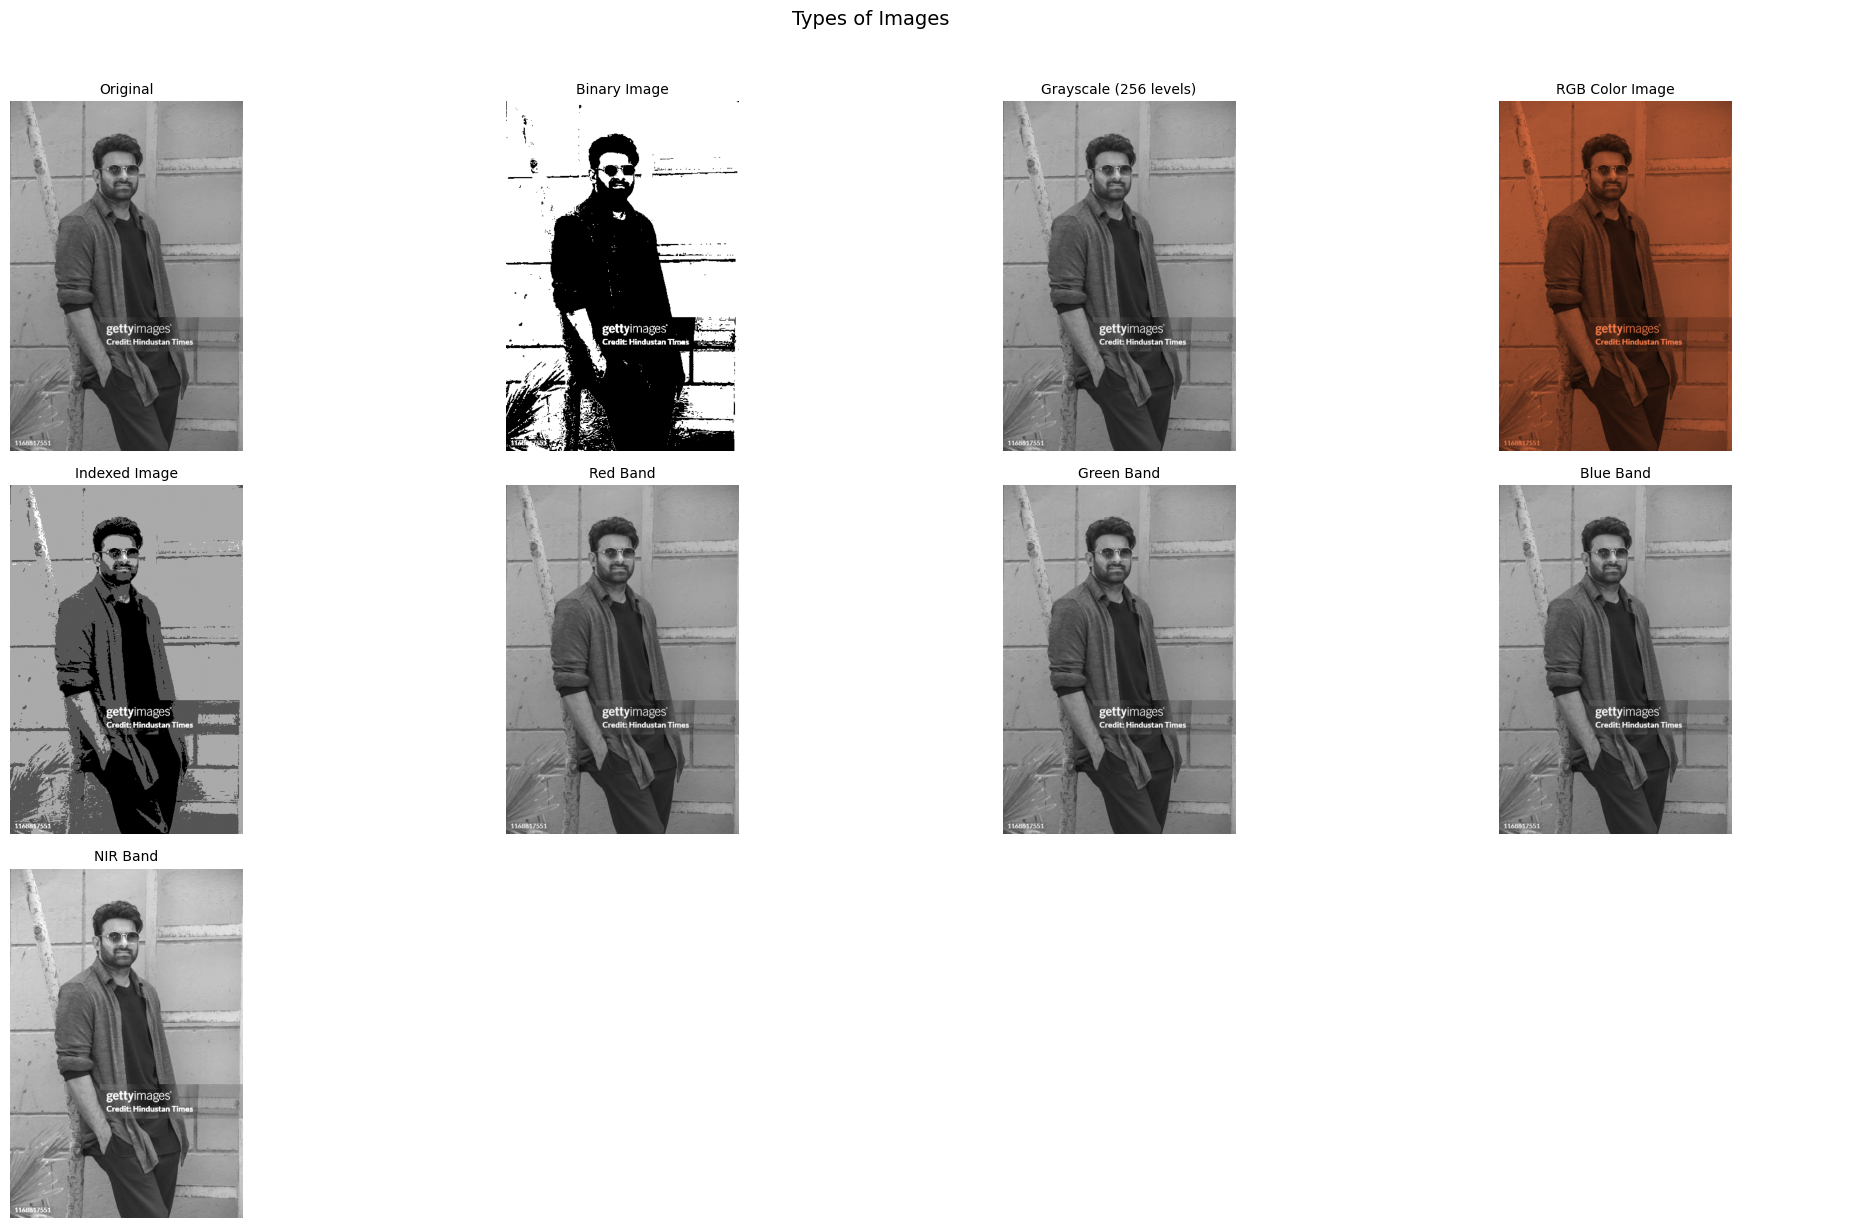


2. IMAGE REPRESENTATION

2. IMAGE REPRESENTATION

[1] Spatial Domain Representation
    ✓ Spatial representation (coordinates x, y)

[2] Frequency Domain Representation
    ✓ Frequency representation (Fourier transform)

[3] Matrix Representation
    ✓ Matrix representation (I[x,y] = value)

[4] Vector Representation
    ✓ Vector representation (flattened 1D array)

[5] Statistical Representation
    ✓ Statistical representation (histogram)


/tmp/ipykernel_679/803475130.py:190: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cv2.line(hist_img, (i, 200), (i, 200 - int(hist_norm[i])), 255, 1)


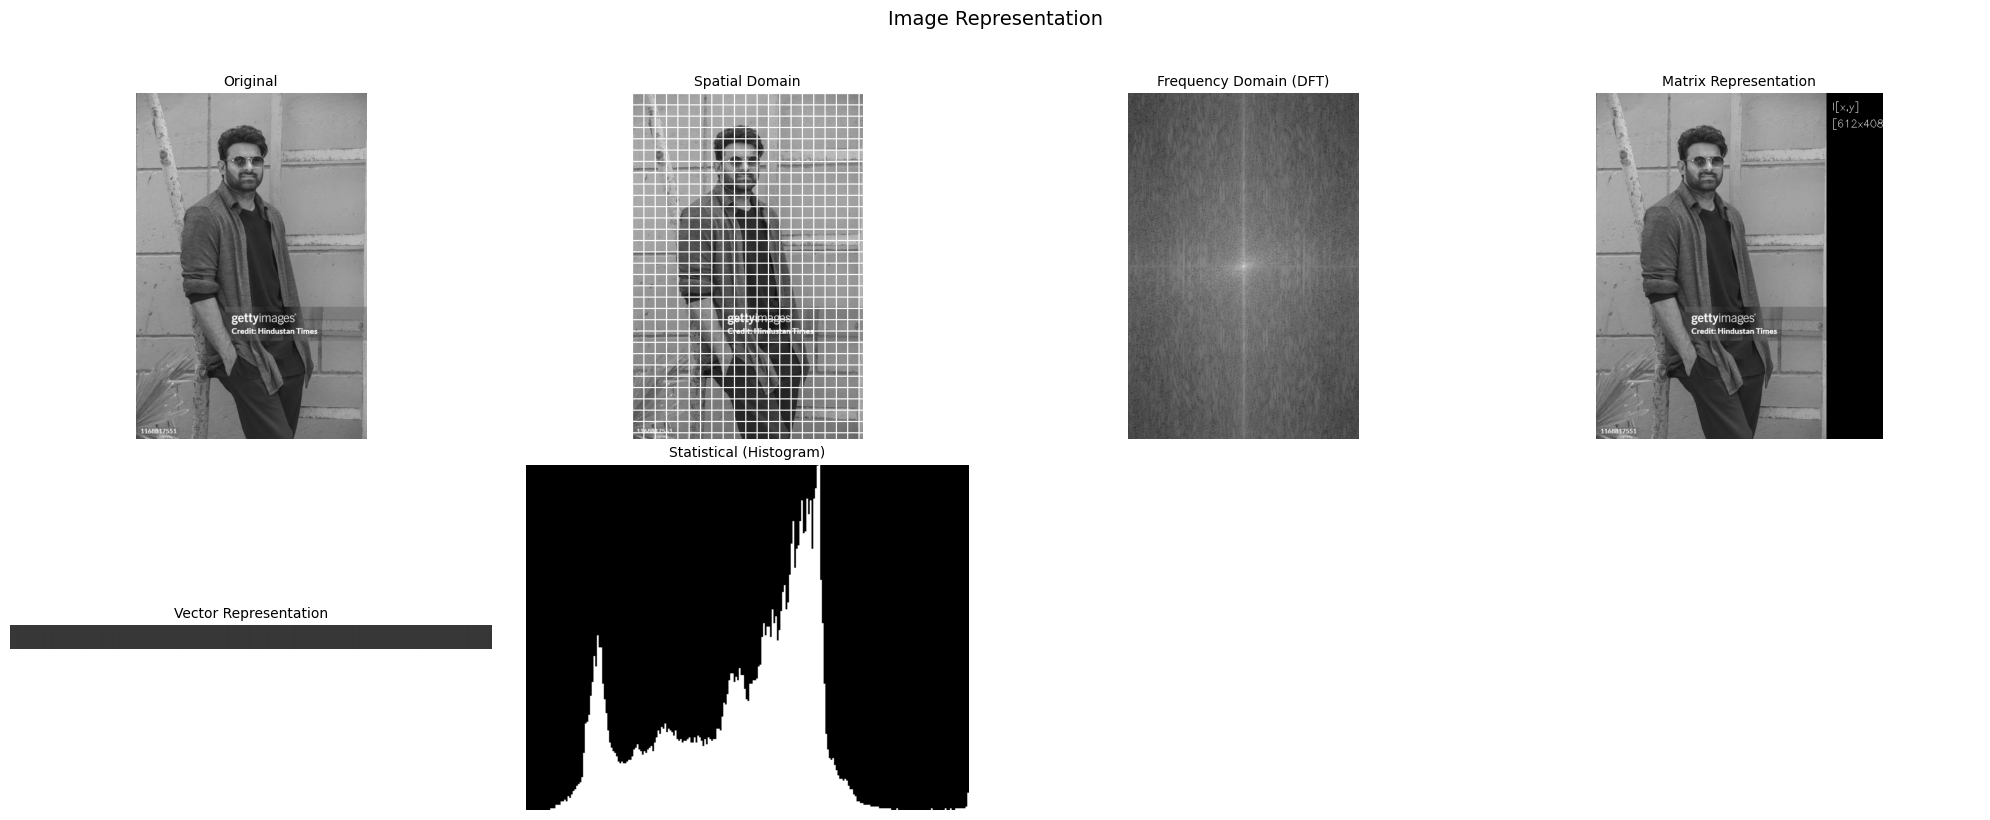


3. SAMPLING

3. SAMPLING - Different Resolutions

Sampling at different resolutions:
  ✓ 102x153 (1/4)
  ✓ 51x76 (1/8)
  ✓ 25x38 (1/16)
  ✓ 12x19 (1/32)
  ✓ 6x9 (1/64)
  ✓ Sampling grid (16x16 pixels)


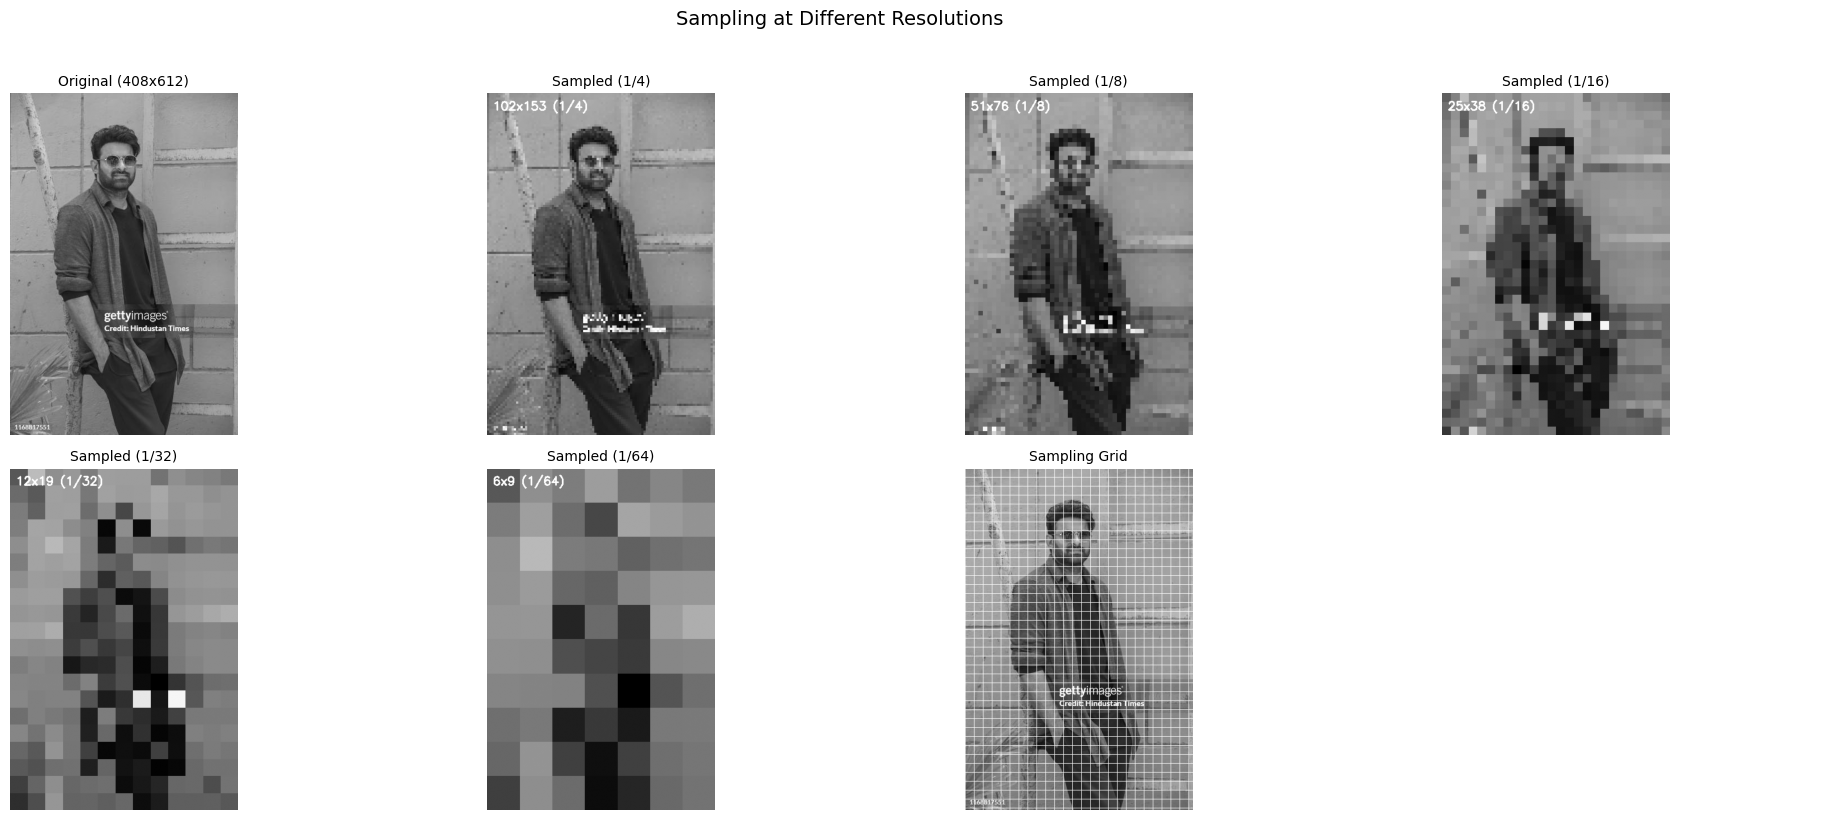


4. QUANTIZATION

4. QUANTIZATION - Different Bit Depths

Quantization at different bit depths:
  ✓ 7-bit (128 levels)
  ✓ 6-bit (64 levels)
  ✓ 5-bit (32 levels)
  ✓ 4-bit (16 levels)
  ✓ 3-bit (8 levels)
  ✓ 2-bit (4 levels)
  ✓ 1-bit (2 levels)
  ✓ Quantization error (difference between original and quantized)


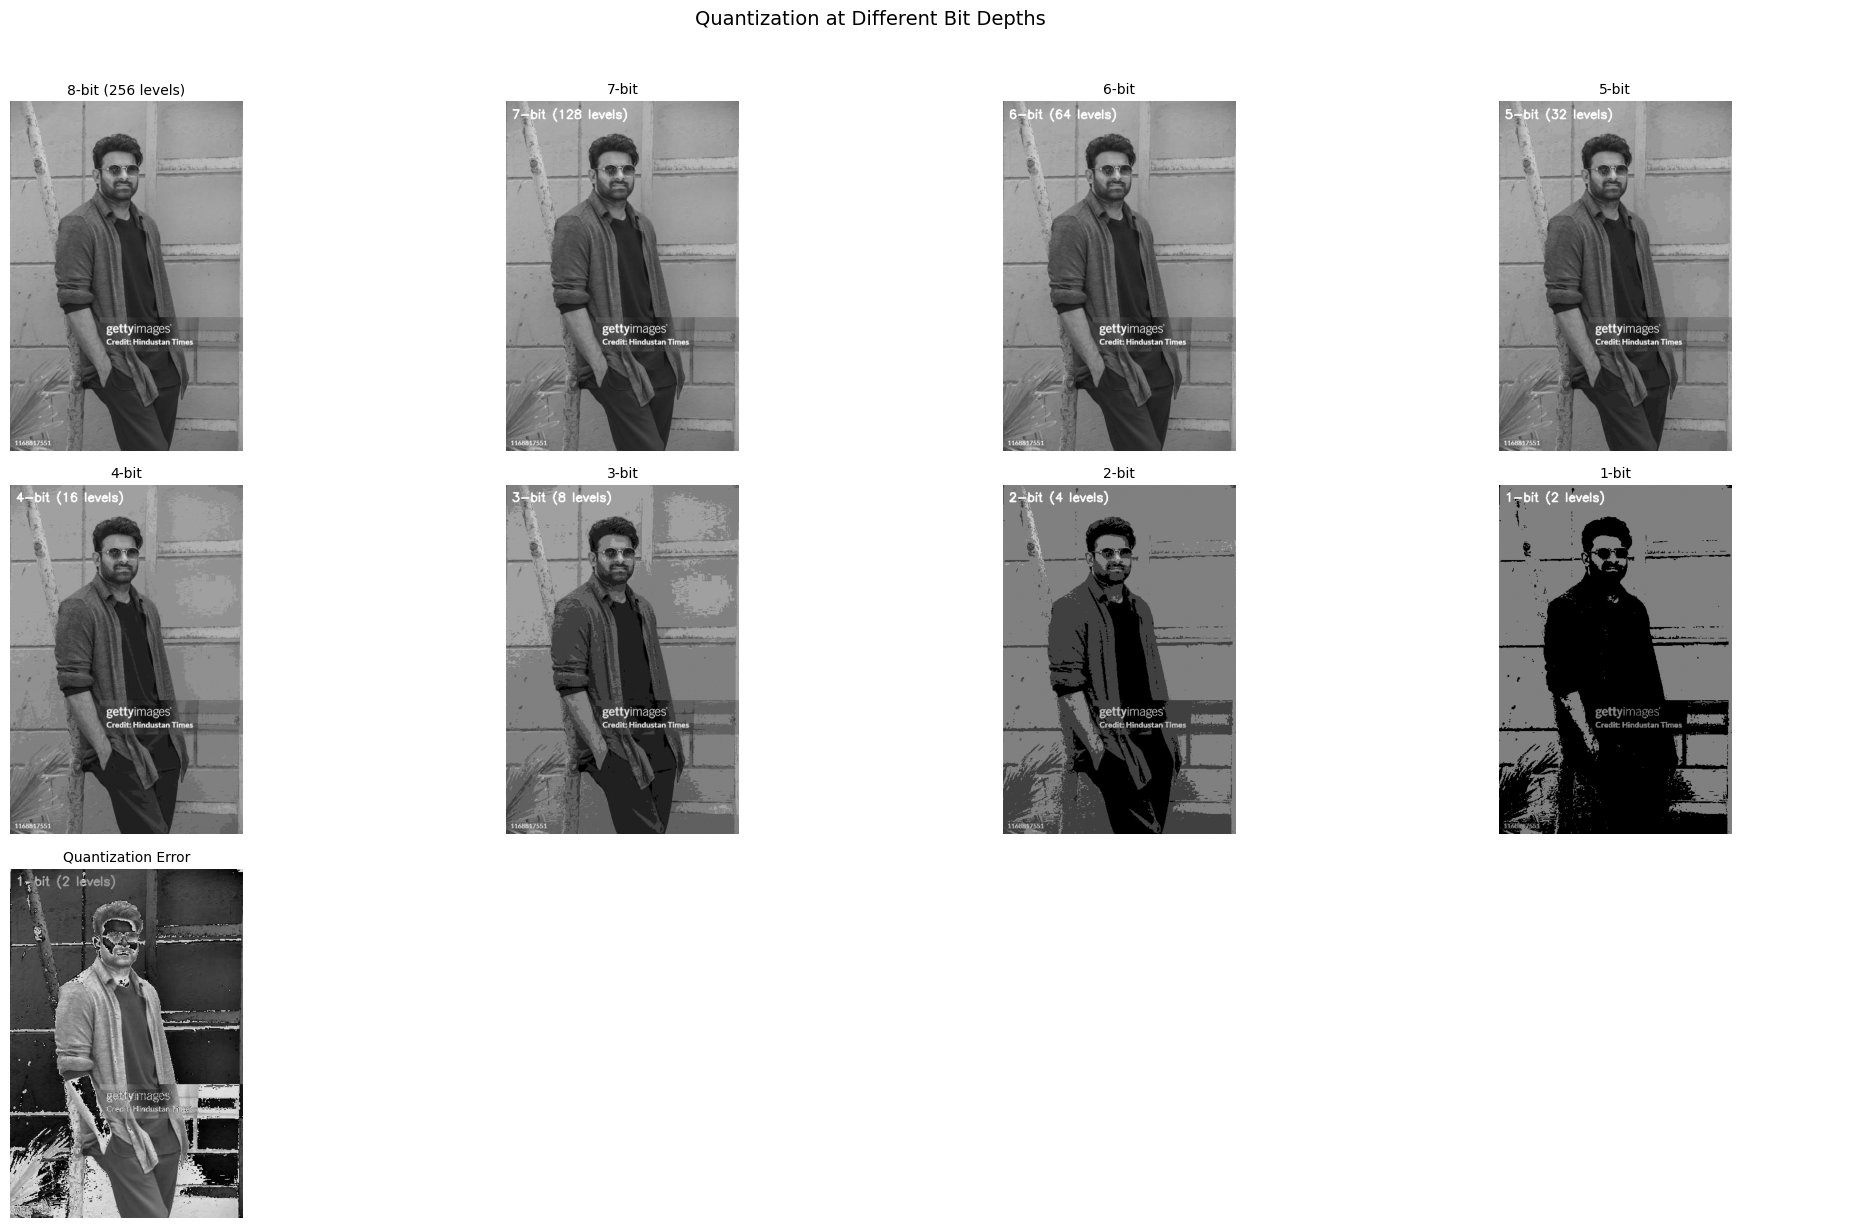


5. IMAGE FORMATION MODEL

5. IMAGE FORMATION MODEL

[1] Illumination Component L(x,y)
    ✓ Illumination component created

[2] Reflectance Component R(x,y)
    ✓ Reflectance component extracted

[3] Image Formation Model: I(x,y) = L(x,y) * R(x,y)
    ✓ Image reconstructed using I = L × R

[4] Noise Addition
    ✓ Gaussian noise added
    ✓ Salt & Pepper noise added
    ✓ Poisson noise added

[5] Degradation Model
    ✓ Degradation model: Blur + Noise


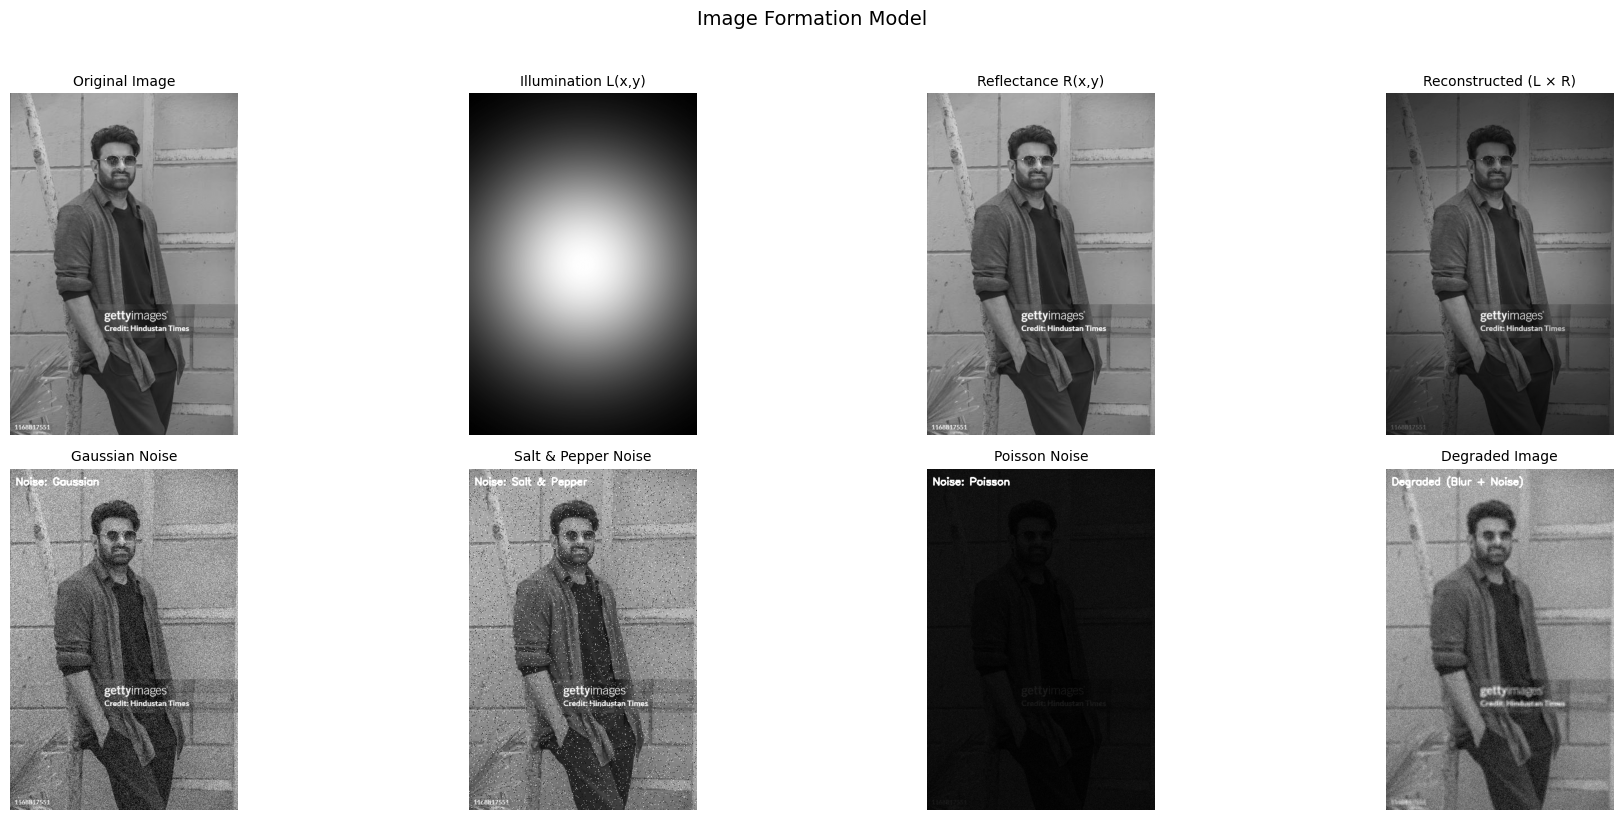


SUMMARY OF ALL DEMONSTRATIONS

1. Types of Images:
   - Binary: 2 levels (0, 1)
   - Grayscale: 256 levels (0-255)
   - Color: 3 channels (R, G, B)
   - Indexed: Color mapping
   - Multispectral: Multiple bands

2. Image Representation:
   - Spatial: I(x,y)
   - Frequency: F(u,v)
   - Matrix: 2D array
   - Vector: 1D array
   - Statistical: Histogram

3. Sampling:
   - Sampling rate: pixels per unit area
   - Higher rate = more detail
   - Lower rate = less detail (aliasing)

4. Quantization:
   - Bit depth: number of levels
   - 8-bit: 256 levels
   - Lower bits: fewer levels (posterization)

5. Image Formation Model:
   - I(x,y) = L(x,y) × R(x,y)
   - L: Illumination component
   - R: Reflectance component
   - Noise: Additive/Impulse noise
   - Degradation: Blur + Noise

Save all results to files? (y/n): y

Saving images...
  ✓ Saved: types_00_Original.png
  ✓ Saved: types_01_Binary_Image.png
  ✓ Saved: types_02_Grayscale_(256_levels).png
  ✓ Saved: types_03_RGB_Color_Image.png
  ✓

In [1]:
# ==================== GOOGLE COLAB VERSION ====================
# Run this entire cell in Google Colab

!pip install opencv-python matplotlib pillow scipy -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io
from PIL import Image
from time import time
import math

# ==================== 1. TYPES OF IMAGES ====================

def demonstrate_image_types(img):
    """
    Demonstrate different types of images:
    1. Binary Image
    2. Grayscale Image
    3. Color Image (RGB)
    4. Indexed Image
    5. Multispectral Image
    """
    print("\n" + "="*70)
    print("1. TYPES OF IMAGES")
    print("="*70)

    results = []
    titles = []

    # Original image
    results.append(img)
    titles.append("Original")

    # 1. Binary Image (2 levels)
    print("\n[1] Binary Image (Black & White)")
    binary_img = np.zeros_like(img)
    # Using Otsu threshold for binary conversion
    threshold = np.mean(img)
    binary_img[img > threshold] = 255
    results.append(binary_img)
    titles.append("Binary Image")
    print(f"    ✓ Binary image created (2 intensity levels)")

    # 2. Grayscale Image (256 levels)
    print("\n[2] Grayscale Image (256 levels)")
    # Already grayscale
    results.append(img)
    titles.append("Grayscale (256 levels)")
    print(f"    ✓ Grayscale image (8-bit, 256 levels)")

    # 3. Color Image (RGB)
    print("\n[3] Color Image (RGB)")
    # Convert grayscale to RGB for visualization
    color_img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    # Add some color variation
    color_img[:, :, 0] = img  # Red channel
    color_img[:, :, 1] = np.clip(img * 0.5, 0, 255).astype(np.uint8)  # Green channel
    color_img[:, :, 2] = np.clip(img * 0.3, 0, 255).astype(np.uint8)  # Blue channel
    results.append(color_img)
    titles.append("RGB Color Image")
    print(f"    ✓ Color image (3 channels: R, G, B)")

    # 4. Indexed Image (Color mapping)
    print("\n[4] Indexed Image")
    # Create indexed image with color mapping
    indexed_img = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            # Map pixel values to indices (0-3)
            indexed_img[i, j] = int(img[i, j] / 64) * 64
    results.append(indexed_img)
    titles.append("Indexed Image")
    print(f"    ✓ Indexed image (4 colors mapped)")

    # 5. Multispectral Image (simulated)
    print("\n[5] Multispectral Image")
    # Create multispectral bands (R, G, B, NIR)
    multispectral = []
    for band in range(4):
        if band == 0:  # Red band
            band_img = img
        elif band == 1:  # Green band
            band_img = np.clip(img * 0.7, 0, 255).astype(np.uint8)
        elif band == 2:  # Blue band
            band_img = np.clip(img * 0.4, 0, 255).astype(np.uint8)
        else:  # NIR band (simulated)
            band_img = np.clip(img * 1.2, 0, 255).astype(np.uint8)
        multispectral.append(band_img)

    # Display multispectral bands
    for i, band in enumerate(multispectral):
        band_names = ['Red Band', 'Green Band', 'Blue Band', 'NIR Band']
        results.append(band)
        titles.append(band_names[i])

    print(f"    ✓ Multispectral image (4 bands: R, G, B, NIR)")

    return results, titles

# ==================== 2. IMAGE REPRESENTATION ====================

def demonstrate_image_representation(img):
    """
    Demonstrate different image representations:
    1. Spatial Domain Representation
    2. Frequency Domain Representation
    3. Matrix Representation
    4. Vector Representation
    5. Statistical Representation
    """
    print("\n" + "="*70)
    print("2. IMAGE REPRESENTATION")
    print("="*70)

    results = []
    titles = []

    # Original image
    results.append(img)
    titles.append("Original")

    # 1. Spatial Domain Representation
    print("\n[1] Spatial Domain Representation")
    spatial_repr = img.copy()
    # Add grid lines to show spatial coordinates
    spatial_repr_grid = spatial_repr.copy()
    for i in range(0, img.shape[0], 20):
        spatial_repr_grid[i:i+2, :] = 255
    for j in range(0, img.shape[1], 20):
        spatial_repr_grid[:, j:j+2] = 255
    results.append(spatial_repr_grid)
    titles.append("Spatial Domain")
    print(f"    ✓ Spatial representation (coordinates x, y)")

    # 2. Frequency Domain Representation (DFT Magnitude)
    print("\n[2] Frequency Domain Representation")
    # Compute FFT
    f_transform = np.fft.fft2(img)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = np.log1p(np.abs(f_shift))
    magnitude_spectrum = (magnitude_spectrum / np.max(magnitude_spectrum)) * 255
    freq_repr = magnitude_spectrum.astype(np.uint8)
    results.append(freq_repr)
    titles.append("Frequency Domain (DFT)")
    print(f"    ✓ Frequency representation (Fourier transform)")

    # 3. Matrix Representation
    print("\n[3] Matrix Representation")
    # Show image as matrix of numbers
    matrix_repr = img.copy()
    # Add text overlay showing matrix values
    h, w = img.shape
    matrix_text = np.zeros((h, w + 100), dtype=np.uint8)
    matrix_text[:, :w] = img
    # Add some matrix notation
    cv2.putText(matrix_text, "I[x,y]", (w+10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, 255, 1)
    cv2.putText(matrix_text, f"[{h}x{w}]", (w+10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, 255, 1)
    results.append(matrix_text)
    titles.append("Matrix Representation")
    print(f"    ✓ Matrix representation (I[x,y] = value)")

    # 4. Vector Representation
    print("\n[4] Vector Representation")
    # Flatten image to vector
    vector_repr = img.flatten()
    # Reshape for visualization
    vector_img = vector_repr.reshape(1, len(vector_repr))
    # Normalize for display
    if vector_img.shape[1] > 1000:
        vector_img = vector_img[:, :1000]  # Show first 1000 values
    vector_img = np.clip(vector_img, 0, 255).astype(np.uint8)
    # Make it visible
    vector_display = np.ones((50, vector_img.shape[1]), dtype=np.uint8) * 128
    vector_display[:vector_img.shape[0], :vector_img.shape[1]] = vector_img
    results.append(vector_display)
    titles.append("Vector Representation")
    print(f"    ✓ Vector representation (flattened 1D array)")

    # 5. Statistical Representation
    print("\n[5] Statistical Representation")
    # Compute histogram
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    # Display histogram as image
    hist_img = np.zeros((200, 256), dtype=np.uint8)
    hist_norm = cv2.normalize(hist, None, 0, 200, cv2.NORM_MINMAX)
    for i in range(256):
        cv2.line(hist_img, (i, 200), (i, 200 - int(hist_norm[i])), 255, 1)
    results.append(hist_img)
    titles.append("Statistical (Histogram)")
    print(f"    ✓ Statistical representation (histogram)")

    return results, titles

# ==================== 3. SAMPLING ====================

def demonstrate_sampling(img):
    """
    Demonstrate image sampling at different resolutions
    """
    print("\n" + "="*70)
    print("3. SAMPLING - Different Resolutions")
    print("="*70)

    results = []
    titles = []

    # Original
    results.append(img)
    titles.append(f"Original ({img.shape[1]}x{img.shape[0]})")

    # Different sampling rates
    sampling_rates = [4, 8, 16, 32, 64]

    print("\nSampling at different resolutions:")

    for rate in sampling_rates:
        h, w = img.shape
        new_h = h // rate
        new_w = w // rate

        # Sample by taking every 'rate' pixel
        sampled = img[::rate, ::rate]

        # Resize back for visualization
        sampled_resized = cv2.resize(sampled, (w, h), interpolation=cv2.INTER_NEAREST)

        # Add text indicating resolution
        text = f"{new_w}x{new_h} (1/{rate})"
        cv2.putText(sampled_resized, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)

        results.append(sampled_resized)
        titles.append(f"Sampled (1/{rate})")

        print(f"  ✓ {text}")

    # Show sampling grid
    grid_img = img.copy()
    for i in range(0, h, 16):
        cv2.line(grid_img, (0, i), (w, i), 255, 1)
    for j in range(0, w, 16):
        cv2.line(grid_img, (j, 0), (j, h), 255, 1)
    results.append(grid_img)
    titles.append("Sampling Grid")
    print(f"  ✓ Sampling grid (16x16 pixels)")

    return results, titles

# ==================== 4. QUANTIZATION ====================

def demonstrate_quantization(img):
    """
    Demonstrate image quantization at different bit depths
    """
    print("\n" + "="*70)
    print("4. QUANTIZATION - Different Bit Depths")
    print("="*70)

    results = []
    titles = []

    # Original (8-bit)
    results.append(img)
    titles.append("8-bit (256 levels)")

    # Different bit depths
    bit_depths = [7, 6, 5, 4, 3, 2, 1]

    print("\nQuantization at different bit depths:")

    for bits in bit_depths:
        levels = 2 ** bits
        # Quantize: reduce number of levels
        quantized = (img / (256 / levels)).astype(np.uint8)
        quantized = (quantized * (256 / levels)).astype(np.uint8)

        text = f"{bits}-bit ({levels} levels)"
        cv2.putText(quantized, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)

        results.append(quantized)
        titles.append(f"{bits}-bit")

        print(f"  ✓ {text}")

    # Show quantization error
    quant_error = cv2.absdiff(img.astype(np.float32), quantized.astype(np.float32))
    quant_error = quant_error.astype(np.uint8)
    results.append(quant_error)
    titles.append("Quantization Error")

    print(f"  ✓ Quantization error (difference between original and quantized)")

    return results, titles

# ==================== 5. IMAGE FORMATION MODEL ====================

def demonstrate_image_formation(img):
    """
    Demonstrate image formation model components:
    1. Illumination Component
    2. Reflectance Component
    3. Image Formation Model: I(x,y) = L(x,y) * R(x,y)
    4. Noise Addition
    5. Degradation Model
    """
    print("\n" + "="*70)
    print("5. IMAGE FORMATION MODEL")
    print("="*70)

    results = []
    titles = []

    # Original
    results.append(img)
    titles.append("Original Image")

    # 1. Illumination Component
    print("\n[1] Illumination Component L(x,y)")
    # Simulate non-uniform illumination
    h, w = img.shape
    y, x = np.mgrid[0:h, 0:w]
    # Create illumination pattern (Gaussian)
    center_y, center_x = h/2, w/2
    illumination = np.exp(-((x-center_x)**2 + (y-center_y)**2) / (2 * (min(h,w)/3)**2))
    illumination = (illumination - np.min(illumination)) / (np.max(illumination) - np.min(illumination))
    illumination = illumination * 0.7 + 0.3  # Range: 0.3 to 1.0

    # Convert to image
    illum_img = (illumination * 255).astype(np.uint8)
    results.append(illum_img)
    titles.append("Illumination L(x,y)")
    print(f"    ✓ Illumination component created")

    # 2. Reflectance Component
    print("\n[2] Reflectance Component R(x,y)")
    # Reflectance is the intrinsic property of the scene
    reflectance = img.astype(np.float32) / 255.0
    # Normalize
    reflectance = (reflectance - np.min(reflectance)) / (np.max(reflectance) - np.min(reflectance))
    reflectance_img = (reflectance * 255).astype(np.uint8)
    results.append(reflectance_img)
    titles.append("Reflectance R(x,y)")
    print(f"    ✓ Reflectance component extracted")

    # 3. Image Formation Model: I = L * R
    print("\n[3] Image Formation Model: I(x,y) = L(x,y) * R(x,y)")
    # Reconstruct image using the model
    L = illumination
    R = reflectance
    reconstructed = (L * R * 255).astype(np.uint8)
    results.append(reconstructed)
    titles.append("Reconstructed (L × R)")
    print(f"    ✓ Image reconstructed using I = L × R")

    # 4. Noise Addition
    print("\n[4] Noise Addition")
    # Add different types of noise
    noise_types = [
        ('Gaussian', 25),
        ('Salt & Pepper', 0.05),
        ('Poisson', 0.1)
    ]

    for noise_type, param in noise_types:
        noisy = img.copy()
        if noise_type == 'Gaussian':
            noise = np.random.normal(0, param, img.shape)
            noisy = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
        elif noise_type == 'Salt & Pepper':
            salt_pepper = np.random.random(img.shape)
            noisy[salt_pepper < param/2] = 0
            noisy[salt_pepper > 1 - param/2] = 255
        elif noise_type == 'Poisson':
            noisy = np.random.poisson(img.astype(np.float32) * param).astype(np.uint8)
            noisy = np.clip(noisy, 0, 255)

        cv2.putText(noisy, f"Noise: {noise_type}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, 255, 2)
        results.append(noisy)
        titles.append(f"{noise_type} Noise")
        print(f"    ✓ {noise_type} noise added")

    # 5. Degradation Model
    print("\n[5] Degradation Model")
    # Blur + noise degradation
    kernel = np.ones((5, 5), np.float32) / 25
    blurred = cv2.filter2D(img, -1, kernel)
    noise = np.random.normal(0, 15, img.shape)
    degraded = np.clip(blurred.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    cv2.putText(degraded, "Degraded (Blur + Noise)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, 255, 2)
    results.append(degraded)
    titles.append("Degraded Image")
    print(f"    ✓ Degradation model: Blur + Noise")

    return results, titles

# ==================== COMPLETE DEMONSTRATION ====================

def display_results_grid(results, titles, title_prefix=""):
    """Display results in a grid"""
    if not results:
        return

    cols = min(4, len(results))
    rows = (len(results) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    if rows == 1:
        axes = axes.reshape(1, -1)

    for idx, (img_result, title) in enumerate(zip(results, titles)):
        row = idx // cols
        col = idx % cols
        if row < rows and col < cols:
            if len(img_result.shape) == 3:
                axes[row, col].imshow(img_result)
            else:
                axes[row, col].imshow(img_result, cmap='gray')
            axes[row, col].set_title(title, fontsize=10)
            axes[row, col].axis('off')

    for idx in range(len(results), rows * cols):
        row = idx // cols
        col = idx % cols
        if row < rows and col < cols:
            axes[row, col].axis('off')

    plt.suptitle(title_prefix, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

def create_test_image(rows=256, cols=256):
    """Create a synthetic test image"""
    img = np.zeros((rows, cols), dtype=np.uint8)

    # Gradient
    grad = np.arange(rows).reshape(-1, 1) / rows * 255

    # Circle
    center_i, center_j = rows/2, cols/2
    y, x = np.ogrid[:rows, :cols]
    dist = np.sqrt((x - center_j)**2 + (y - center_i)**2)
    circle = 200 * (dist < 50)

    # Sinusoidal pattern
    sin_pattern = 128 + 100 * np.sin(y/15) * np.cos(x/15)

    # Square
    square = np.zeros((rows, cols))
    square[50:100, 50:100] = 150

    # Noise
    noise = np.random.randint(-20, 21, (rows, cols))

    # Combine
    img = ((grad + circle + sin_pattern + square + noise) / 4).astype(np.uint8)
    return np.clip(img, 0, 255).astype(np.uint8)

def main():
    print("\n" + "="*70)
    print("IMAGE PROCESSING DEMONSTRATION")
    print("Topics: Types of Images, Representation, Sampling, Quantization, Formation")
    print("="*70)
    print("\n✅ All operations use mathematical formulas from scratch")
    print("✅ Supports any image format (JPG, PNG, BMP, TIFF, GIF, WEBP, PGM)")
    print("✅ Auto-resizes to 720p max")
    print("\n" + "="*70)

    # Upload image
    print("\n📤 Please upload an image:")
    print("Click 'Choose File' button below and select your image")
    print("Or press 'Cancel' to use test image")
    print("-"*50)

    uploaded = files.upload()

    if not uploaded:
        print("\n⚠ No file uploaded. Using test image...")
        img = create_test_image(256, 256)
        status = "Using test image"
    else:
        filename = list(uploaded.keys())[0]
        content = uploaded[filename]

        pil_img = Image.open(io.BytesIO(content))
        if pil_img.mode != 'L':
            pil_img = pil_img.convert('L')
        img = np.array(pil_img, dtype=np.uint8)
        status = f"✓ Loaded: {filename} ({img.shape[1]}x{img.shape[0]})"

    print(f"\n{status}")

    # Resize to 720p max
    max_dim = 720
    h, w = img.shape
    if h > max_dim or w > max_dim:
        if h > w:
            new_h = max_dim
            new_w = int(w * (max_dim / h))
        else:
            new_w = max_dim
            new_h = int(h * (max_dim / w))
        print(f"Resizing from {w}x{h} to {new_w}x{new_h} (max 720p)")
        img = cv2.resize(img, (new_w, new_h))

    # ===== 1. TYPES OF IMAGES =====
    print("\n" + "="*70)
    print("1. TYPES OF IMAGES")
    print("="*70)
    results1, titles1 = demonstrate_image_types(img)
    display_results_grid(results1, titles1, "Types of Images")

    # ===== 2. IMAGE REPRESENTATION =====
    print("\n" + "="*70)
    print("2. IMAGE REPRESENTATION")
    print("="*70)
    results2, titles2 = demonstrate_image_representation(img)
    display_results_grid(results2, titles2, "Image Representation")

    # ===== 3. SAMPLING =====
    print("\n" + "="*70)
    print("3. SAMPLING")
    print("="*70)
    results3, titles3 = demonstrate_sampling(img)
    display_results_grid(results3, titles3, "Sampling at Different Resolutions")

    # ===== 4. QUANTIZATION =====
    print("\n" + "="*70)
    print("4. QUANTIZATION")
    print("="*70)
    results4, titles4 = demonstrate_quantization(img)
    display_results_grid(results4, titles4, "Quantization at Different Bit Depths")

    # ===== 5. IMAGE FORMATION MODEL =====
    print("\n" + "="*70)
    print("5. IMAGE FORMATION MODEL")
    print("="*70)
    results5, titles5 = demonstrate_image_formation(img)
    display_results_grid(results5, titles5, "Image Formation Model")

    # ===== SUMMARY =====
    print("\n" + "="*70)
    print("SUMMARY OF ALL DEMONSTRATIONS")
    print("="*70)
    print("\n1. Types of Images:")
    print("   - Binary: 2 levels (0, 1)")
    print("   - Grayscale: 256 levels (0-255)")
    print("   - Color: 3 channels (R, G, B)")
    print("   - Indexed: Color mapping")
    print("   - Multispectral: Multiple bands")

    print("\n2. Image Representation:")
    print("   - Spatial: I(x,y)")
    print("   - Frequency: F(u,v)")
    print("   - Matrix: 2D array")
    print("   - Vector: 1D array")
    print("   - Statistical: Histogram")

    print("\n3. Sampling:")
    print("   - Sampling rate: pixels per unit area")
    print("   - Higher rate = more detail")
    print("   - Lower rate = less detail (aliasing)")

    print("\n4. Quantization:")
    print("   - Bit depth: number of levels")
    print("   - 8-bit: 256 levels")
    print("   - Lower bits: fewer levels (posterization)")

    print("\n5. Image Formation Model:")
    print("   - I(x,y) = L(x,y) × R(x,y)")
    print("   - L: Illumination component")
    print("   - R: Reflectance component")
    print("   - Noise: Additive/Impulse noise")
    print("   - Degradation: Blur + Noise")

    # Save option
    print("\n" + "="*70)
    save = input("Save all results to files? (y/n): ").strip().lower()
    if save == 'y':
        print("\nSaving images...")
        all_results = [
            (results1, titles1, "types"),
            (results2, titles2, "representation"),
            (results3, titles3, "sampling"),
            (results4, titles4, "quantization"),
            (results5, titles5, "formation")
        ]

        for res_group, titles_group, prefix in all_results:
            for idx, (img_result, title) in enumerate(zip(res_group, titles_group)):
                filename = f"{prefix}_{idx:02d}_{title.replace(' ', '_').replace('/', '_')}.png"
                if len(img_result.shape) == 3:
                    cv2.imwrite(filename, cv2.cvtColor(img_result, cv2.COLOR_RGB2BGR))
                else:
                    cv2.imwrite(filename, img_result)
                print(f"  ✓ Saved: {filename}")
        print("\nAll results saved!")

if __name__ == "__main__":
    main()